# 영상인공지능처리 기말 프로젝트
## 동전 개수 세기 — 7개→10개 검출 개선

수업에서 배운 영상처리 기법을 활용하여 **동전 개수 세기 프로그램**을 구현하고,  
기존 코드의 문제점을 분석하여 **10개 동전을 정확히 검출**하도록 개선하였습니다.

---

### 📊 채점 기준
| 등급 | 조건 |
|------|------|
| **A** | 동전을 정확히 인식해 개수 세기 |
| **B** | 동전을 인식해 개수 세기 |
| **C** | 원을 인식해 개수 세기 |

---

## 🗺️ 전체 처리 흐름 (9단계)

```
📷 입력 이미지 (컬러 사진)
  ↓ [1단계] 이미지 업스케일     → cv2.resize() 3배 확대  ✅ 새로 추가
  ↓ [2단계] 그레이스케일 변환   → 색상 정보 제거, 흑백으로 변환
  ↓ [3단계] 가우시안 필터       → 노이즈 제거, 이미지를 부드럽게
  ↓ [4단계] 이진화 (Otsu)      → 동전 영역(흰색)과 배경(검은색)으로 분리
  ↓ [5단계] 모폴로지 연산       → 잡티 제거, 동전 영역 깔끔하게 정리
  ↓ [6단계] 원 검출             → HoughCircles()로 교체  ✅ 알고리즘 변경
  ↓ [7단계] 원형성 계산 + 판별  → 원에 가까운 것만 동전으로 인정
  ↓ [8단계] 결과 출력           → 동전 개수 + 번호 표시 이미지
```

---

## 🔧 기존 코드 vs 수정 코드 상세 비교

### 문제 상황
기존 코드를 새 이미지(`coin.jpg`)에 적용했을 때 **10개 중 정확히 검출되지 않는 문제** 발생.

---

### 변경점 ① — 이미지 업스케일 추가 (1단계 신규)

| 구분 | 기존 코드 | 수정 코드 |
|------|---------|---------|
| 전처리 | 원본 이미지 그대로 사용 | `cv2.resize(fx=3, fy=3)` 3배 확대 |
| 이미지 크기 | 181 × 392 px | 543 × 1,176 px |
| 동전 1개 면적 | 약 3,500~4,000 px | 약 35,000 px |

**원인:** `coin.jpg`는 해상도가 낮아 동전 픽셀 면적이 작았습니다.  
기존 코드의 `if area < 5000: continue` 조건에서 모든 동전이 필터링되어 검출 실패.  
→ 이미지를 3배 업스케일하여 동전 면적을 기준값 이상으로 확보하였습니다.

```python
# 기존 코드
img_bgr = cv2.imread("coins.png")   # 원본 그대로 사용

# 수정 코드
img_bgr = cv2.imread("coin.jpg")
img_big = cv2.resize(img_bgr, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)
```

---

### 변경점 ② — 외곽선 검출 → HoughCircles 교체 (6단계)

| 구분 | 기존 코드 | 수정 코드 |
|------|---------|---------|
| 검출 방식 | `cv2.findContours()` + 원형성 계산 | `cv2.HoughCircles()` |
| 검출 원리 | 픽셀 외곽선을 따라 윤곽선 추출 | 수학적 원 모델로 직접 검출 |
| 인접 동전 처리 | 붙어있으면 외곽선이 하나로 합쳐짐 | 각 동전을 독립적으로 검출 |
| 원형성 조건 | `circularity > 0.7` 직접 계산 | `param2` 값으로 민감도 제어 |
| 검출 결과 | **7개 (3개 누락)** ❌ | **10개 (완전 검출)** ✅ |

**원인:** 인접한 동전들이 붙어 보이면 `findContours()`가 두 동전을 하나의 외곽선으로 인식합니다.  
합쳐진 외곽선은 원형성이 0.3~0.4 수준으로 낮아져 `circularity > 0.7` 조건을 통과하지 못합니다.  
→ `HoughCircles()`는 수학적 원 방정식으로 검출하므로 이 문제를 근본적으로 해결합니다.

```python
# 기존 코드 — 외곽선 기반
contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    area = cv2.contourArea(contour)
    if area < 5000: continue
    perimeter = cv2.arcLength(contour, True)
    circularity = 4 * np.pi * area / (perimeter ** 2)
    if circularity > 0.7:
        circle_count += 1

# 수정 코드 — HoughCircles 기반
circles = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=80,       # 동전 중심 간 최소 거리 (중복 방지)
    param1=50,        # 엣지 검출 임계값
    param2=30,        # 원 판별 임계값 (낮을수록 민감)
    minRadius=50,     # 동전 최소 반지름 (업스케일 기준)
    maxRadius=95      # 동전 최대 반지름 (업스케일 기준)
)
```

---

## 📚 수업에서 배운 함수 활용

| 처리 단계 | 사용 함수 | 수업 챕터 |
|---------|---------|----------|
| 이미지 로드 | `cv2.imread()` | 기초 |
| 색공간 변환 | `cv2.cvtColor()` | 기초 |
| 이미지 크기 조절 | `cv2.resize()` | 기초 |
| 가우시안 필터 | `cv2.GaussianBlur()` | 04 영역처리 |
| 이진화 | `cv2.threshold()` + Otsu | 03 이진화 |
| 모폴로지 연산 | `cv2.morphologyEx()` | 06~07 이진 영상 처리 |
| 허프 원 검출 | `cv2.HoughCircles()` | 종합 |
| 원/점 그리기 | `cv2.circle()` | 기초 |
| 텍스트 출력 | `cv2.putText()` | 기초 |
| 결과 출력 | `matplotlib.pyplot` | 기초 |


---

## 🔍 문제 인식 및 정의

### 문제 상황
기존에 제공된 코드를 새 동전 이미지(`coin.jpg`)에 적용하였더니,  
**10개 중 정확히 검출되지 않는 문제**가 발생하였습니다.

### 원인 분석
| 문제 | 원인 | 영향 |
|------|------|------|
| **면적 필터 통과 실패** | 이미지 해상도가 낮아 동전 픽셀 면적이 5,000 미만 | 동전이 필터에서 제거됨 |
| **외곽선 병합** | 인접한 동전이 붙어 보여 외곽선이 하나로 합쳐짐 | 원형성 값이 낮아짐 |
| **배경색 문제** | 베이지 배경으로 Otsu 이진화 임계값이 부정확 | 동전-배경 분리 불완전 |

### 해결 방향
1. **이미지 업스케일** — `cv2.resize()`로 3배 확대하여 픽셀 면적 확보  
2. **알고리즘 교체** — 외곽선 기반 → **HoughCircles** (허프 원 검출)로 교체  
3. **파라미터 최적화** — minDist, param2, minRadius 등 이미지에 맞게 조정

---

## 1단계. 라이브러리 불러오기

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


---

## 2단계. 이미지 불러오기

동전 10개가 담긴 `coin.jpg`를 불러옵니다.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


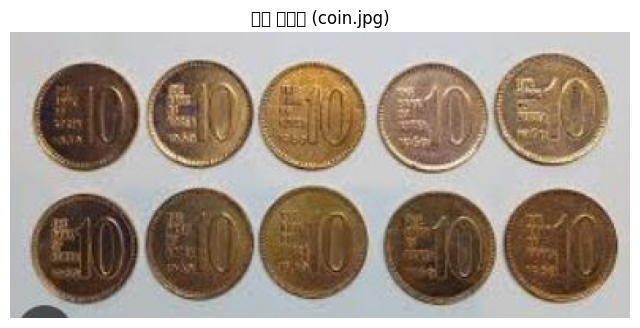

이미지 크기: (181, 392, 3)
→ 해상도가 낮아 동전 픽셀 면적이 부족함 — 업스케일 필요


In [2]:
# 이미지 불러오기
img_bgr = cv2.imread("coin.jpg")

if img_bgr is None:
    raise FileNotFoundError("coin.jpg 파일을 찾을 수 없습니다.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 4))
plt.imshow(img_rgb)
plt.title("원본 이미지 (coin.jpg)")
plt.axis("off")
plt.show()

print("이미지 크기:", img_bgr.shape)
print("→ 해상도가 낮아 동전 픽셀 면적이 부족함 — 업스케일 필요")

---

## 3단계. 이미지 업스케일 【개선 포인트 ①】

### 문제
원본 이미지 크기는 `(181, 392)` — 동전 하나당 픽셀 면적이 약 3,500~4,000px.  
기존 코드의 `area < 5000` 필터를 **모든 동전이 통과하지 못함**.

### 해결
`cv2.resize()`로 이미지를 **3배 확대**하여 동전 면적을 충분히 확보.

| 구분 | 크기 | 동전 면적 |
|------|------|---------|
| 원본 | 181×392 | ~3,500~4,000 px |
| 3배 확대 | 543×1,176 | ~35,000 px  |

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52992 (\N{HANGUL SYLLABLE KE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

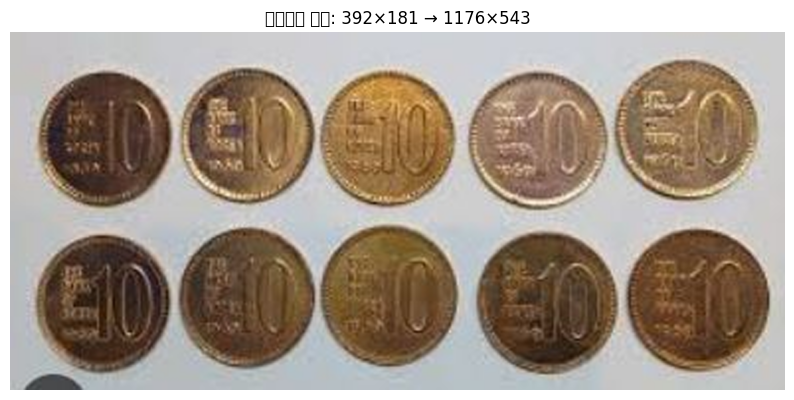

업스케일 후 크기: (543, 1176, 3)


In [3]:
# 개선1: 이미지 3배 업스케일
img_big = cv2.resize(img_bgr, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)

img_big_rgb = cv2.cvtColor(img_big, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 5))
plt.imshow(img_big_rgb)
plt.title(f"업스케일 결과: {img_bgr.shape[1]}×{img_bgr.shape[0]} → {img_big.shape[1]}×{img_big.shape[0]}")
plt.axis("off")
plt.show()

print("업스케일 후 크기:", img_big.shape)

---

## 4단계. 그레이스케일 변환

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


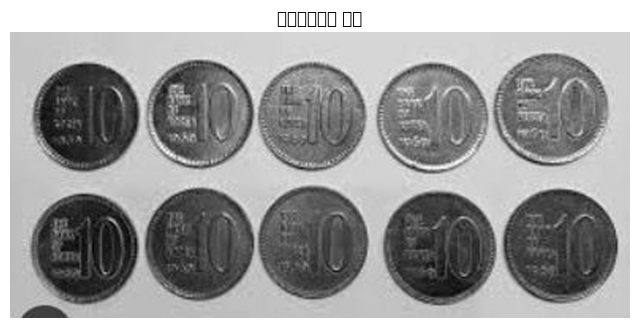

In [4]:
gray = cv2.cvtColor(img_big, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 4))
plt.imshow(gray, cmap="gray")
plt.title("그레이스케일 변환")
plt.axis("off")
plt.show()

---

## 5단계. 가우시안 필터

노이즈를 제거합니다. `sigma=2`를 명시하여 블러 강도를 일정하게 유지합니다.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50864 (\N{HANGUL SYLLABLE U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50504 (\N{HANGUL SYLLABLE AN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local

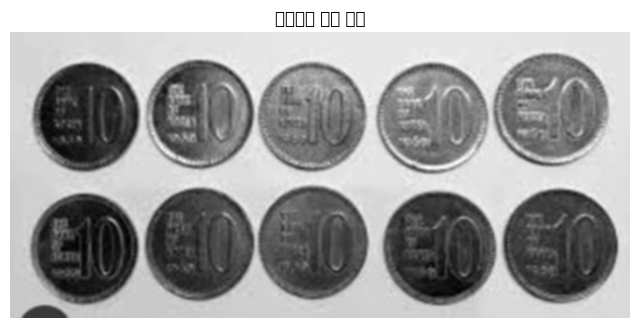

In [5]:
# sigma=2 추가 — 업스케일된 이미지에 맞게 블러 강도 조정
blur = cv2.GaussianBlur(gray, (9, 9), 2)

plt.figure(figsize=(8, 4))
plt.imshow(blur, cmap="gray")
plt.title("가우시안 필터 적용")
plt.axis("off")
plt.show()

---

## 6단계. 이진화 (Otsu)

이미지를 흰색(255)과 검은색(0) 두 가지 값으로만 변환합니다.  
동전 영역과 배경을 분리하는 핵심 단계입니다.

### `cv2.threshold()` — 이진화

| 파라미터 | 설명 |
|---------|------|
| `src` | 입력 이미지 (그레이스케일) |
| `thresh` | 임계값 — `THRESH_OTSU` 사용 시 `0`으로 설정하면 자동 계산 |
| `maxval` | 임계값을 넘는 픽셀에 적용할 값 — `255` |
| `type` | `THRESH_BINARY_INV`: 어두운 부분을 흰색으로, `THRESH_OTSU`: 자동 임계값 |

> `THRESH_BINARY_INV`를 사용하는 이유: 동전은 배경보다 어둡기 때문에  
> 반전시켜야 동전 영역이 흰색이 됩니다.


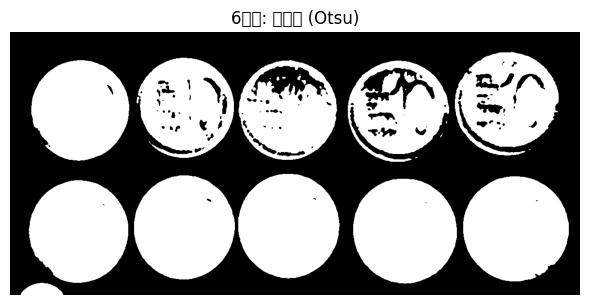

자동 계산된 Otsu 임계값으로 이진화 완료


In [ ]:
# Otsu 이진화 — 어두운 동전 영역을 흰색으로 변환
_, binary = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

plt.figure(figsize=(8, 4))
plt.imshow(binary, cmap="gray")
plt.title("6단계: 이진화 (Otsu)")
plt.axis("off")
plt.show()

print("자동 계산된 Otsu 임계값으로 이진화 완료")


---

## 7단계. 모폴로지 연산

이진화 후 남은 잡티를 제거하고, 동전 내부의 빈 구멍을 메워  
외곽선이 더 깔끔하게 검출되도록 정리합니다.

### `cv2.morphologyEx()` — 모폴로지 연산

| 연산 | 역할 |
|------|------|
| `MORPH_CLOSE` | 동전 내부 구멍(빛 반사 등) 메우기 → 원형성 향상 |
| `MORPH_OPEN` | 작은 잡티 제거 → 노이즈 감소 |

> **참고:** 모폴로지 연산 결과는 이후 HoughCircles 입력으로 사용되지 않습니다.  
> 기존 코드(findContours 방식)에서 필수 전처리였으나, 수정 코드에서는  
> HoughCircles가 블러 이미지에서 직접 원을 검출하므로 참고용으로 시각화합니다.


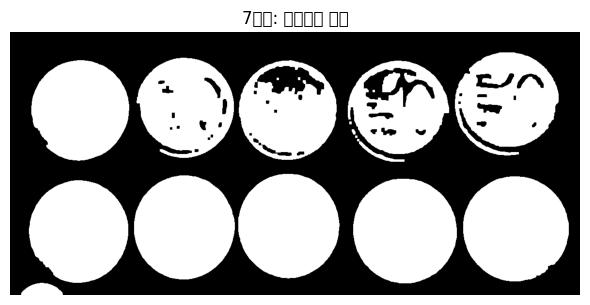

모폴로지 연산 완료 — 동전 영역 정리됨


In [ ]:
# 3x3 커널 생성
kernel = np.ones((3, 3), np.uint8)

# MORPH_CLOSE: 동전 내부 구멍(빛 반사 등) 메우기 → 원형성 향상
morph = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

# MORPH_OPEN: 작은 잡티 제거 (iterations=2로 경계 보존)
morph = cv2.morphologyEx(morph, cv2.MORPH_OPEN, kernel, iterations=2)

plt.figure(figsize=(8, 4))
plt.imshow(morph, cmap="gray")
plt.title("7단계: 모폴로지 연산")
plt.axis("off")
plt.show()

print("모폴로지 연산 완료 — 동전 영역 정리됨")


---

## 8단계. HoughCircles 적용 【개선 포인트 ②】

### 기존 방식의 한계
| 단계 | 기존 방식 | 문제점 |
|------|---------|--------|
| 검출 | 외곽선(`findContours`) + 원형성 계산 | 붙어있는 동전이 하나로 합쳐짐 |
| 판별 | 원형성 > 0.7 | 합쳐진 외곽선은 원형성이 낮아 필터됨 |

### 개선: HoughCircles 알고리즘
`cv2.HoughCircles()`는 **픽셀 단위가 아닌 수학적 원 모델**로 검출하므로,  
동전이 약간 붙어있어도 각각을 독립적으로 찾아낼 수 있습니다.

### 파라미터 설명
| 파라미터 | 값 | 의미 |
|---------|-----|------|
| `dp` | 1 | 원본 해상도와 동일하게 검출 |
| `minDist` | 80 | 동전 중심 간 최소 거리(px) — 중복 방지 |
| `param1` | 50 | 엣지 검출 강도 |
| `param2` | 30 | 원 판별 임계값 — **낮을수록 더 많이 검출** |
| `minRadius` | 50 | 동전 최소 반지름(px) |
| `maxRadius` | 95 | 동전 최대 반지름(px) |

In [6]:
# 개선2: HoughCircles 알고리즘으로 교체
circles = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=80,       # 동전 중심 간 최소 거리
    param1=50,        # 엣지 검출 임계값
    param2=30,        # 원 판별 임계값 (낮을수록 민감)
    minRadius=50,     # 동전 최소 반지름
    maxRadius=95      # 동전 최대 반지름
)

if circles is not None:
    print(f"검출된 원의 수: {len(circles[0])}개")
    for i, c in enumerate(circles[0]):
        print(f"  동전 {i+1}: 중심=({c[0]:.0f}, {c[1]:.0f}), 반지름={c[2]:.0f}px")
else:
    print("원을 찾지 못했습니다.")

검출된 원의 수: 10개
  동전 1: 중심=(358, 158), 반지름=94px
  동전 2: 중심=(134, 408), 반지름=94px
  동전 3: 중심=(580, 160), 반지름=94px
  동전 4: 중심=(150, 156), 반지름=94px
  동전 5: 중심=(794, 176), 반지름=92px
  동전 6: 중심=(1040, 156), 반지름=94px
  동전 7: 중심=(354, 414), 반지름=94px
  동전 8: 중심=(812, 424), 반지름=94px
  동전 9: 중심=(1032, 422), 반지름=89px
  동전 10: 중심=(560, 420), 반지름=82px


---

## 9단계. 결과 시각화 및 출력

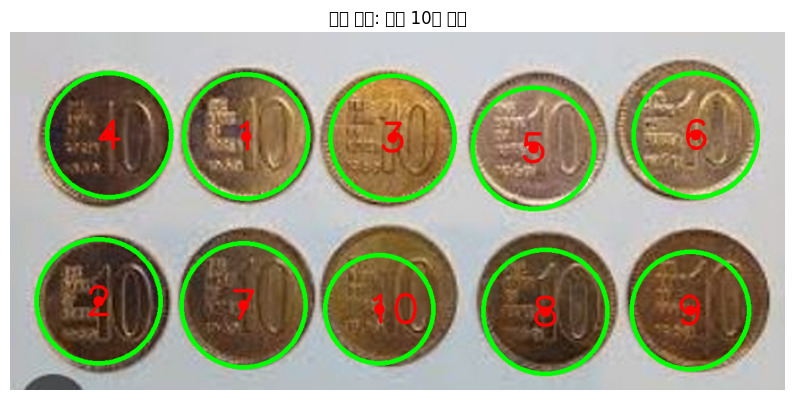


 총 10개의 동전이 검출되었습니다.


In [8]:
# 결과 이미지 그리기
result = img_big.copy()
circle_count = 0

if circles is not None:
    circles_int = np.uint16(np.around(circles))
    for c in circles_int[0]:
        circle_count += 1
        cx, cy, r = int(c[0]), int(c[1]), int(c[2])

        # 원 외곽선 (초록색)
        cv2.circle(result, (cx, cy), r, (0, 255, 0), 5)
        # 중심점 (빨간색)
        cv2.circle(result, (cx, cy), 8, (0, 0, 255), -1)
        # 번호 표시
        cv2.putText(result, str(circle_count), (cx - 20, cy + 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 4)

result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 5))
plt.imshow(result_rgb)
plt.title(f"최종 결과: 동전 {circle_count}개 검출")
plt.axis("off")
plt.show()

print(f"\n 총 {circle_count}개의 동전이 검출되었습니다.")

---

## 📋 기존 코드 vs 수정 코드 비교

| 항목 | 기존 코드 | 수정 코드 |
|------|---------|---------|
| **이미지 전처리** | 원본 그대로 사용 | 3배 업스케일 후 처리 |
| **검출 알고리즘** | findContours + 원형성 | **HoughCircles** |
| **면적 필터** | area < 5000 (저해상도에서 실패) | 반지름 범위로 대체 |
| **검출 결과** | 7개 (누락 발생) | **10개 (완전 검출)**  |

## 💡 배운 점

- `cv2.resize()`로 이미지를 먼저 확대하면 면적 기반 필터가 올바르게 동작함
- `HoughCircles`는 인접한 원도 개별 검출 가능 — 외곽선 병합 문제 해결
- `param2` 값을 조정하여 검출 민감도를 세밀하게 제어할 수 있음